# Прогнозування потреби в технічному обслуговуванні виробничого обладнання
## Курсовий проєкт — IoT Predictive Maintenance

**Набори даних:**
- Smart Manufacturing IoT-Cloud Monitoring Dataset (Kaggle, 2025-03-03)
- Real-Time IoT-Driven Production System Dataset (Kaggle, 2025-03-10)

**Цільова змінна:** `maintenance_required` (бінарна: 0/1)

**Інструменти:** Pandas, NumPy, Scikit-learn, XGBoost, LightGBM, Matplotlib, Seaborn

In [ ]:
# ── Імпорт бібліотек ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost не встановлено. Встановіть: pip install xgboost')

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM не встановлено. Встановіть: pip install lightgbm')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
print('Імпорт завершено.')

Імпорт завершено.


---
# Розділ 1. Характеристика предметної області та підготовка даних
## 1.1. Завантаження та нормалізація ідентифікаторів

In [4]:
# ── 1.1 Завантаження датасету ─────────────────────────────────────────────────
DATA_PATH = 'data/main_dataset.csv'   # змініть шлях за потреби

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Розмір завантаженого датасету: {df_raw.shape}')
df_raw.head(6)

Розмір завантаженого датасету: (102460, 13)


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0.0,106.0,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0.0,320.0,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1.0,19.0,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1.0,10.0,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0.0,65.0,Vibration Issue,0.0,1
5,2025-01-01 00:05:00,21,70.88,38.38,51.01,3.19,3.24,1,0.0,381.0,Normal,0.0,0


In [5]:
# ── 1.1.1 Нормалізація machine_id ─────────────────────────────────────────────
# Проблема: перший датасет має числові ID (1–50),
# другий — рядкові ('M001'–'M004').
# Рішення: видалити префікс 'M' і привести до int.

def normalize_machine_id(x):
    """Перетворює 'M003' → 3, а числові значення залишає без змін."""
    if isinstance(x, str) and x.upper().startswith('M'):
        return int(x[1:])
    return int(x)

df_raw['machine_id'] = df_raw['machine_id'].apply(normalize_machine_id)

# Перевірка
print('dtype після нормалізації:', df_raw['machine_id'].dtype)
print('Унікальних machine_id   :', df_raw['machine_id'].nunique())
print('Мін / Макс ID           :', df_raw['machine_id'].min(), '/', df_raw['machine_id'].max())
print('Нульових значень        :', df_raw['machine_id'].isna().sum())

dtype після нормалізації: int64
Унікальних machine_id   : 50
Мін / Макс ID           : 1 / 50
Нульових значень        : 0


## 1.2. Профілювання структури даних (п. 1.3.1)
### Таблиця 1.1 – Узагальнені статистики та пропуски

In [6]:
# ── 1.2 Профілювання ──────────────────────────────────────────────────────────
df = df_raw.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['machine_id', 'timestamp']).reset_index(drop=True)

print('=== Загальна інформація ===')
print(f'Рядків: {df.shape[0]:,} | Стовпців: {df.shape[1]}')
print(f'Дублікатів: {df.duplicated().sum()}')
print()

# Таблиця 1.1
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
stats = df.describe().T[['mean','std','min','50%','max']].rename(columns={'50%':'median'})
table_1_1 = stats.join(missing.rename('missing_count')).join(missing_pct.rename('missing_%'))
print('=== Таблиця 1.1 — Узагальнені статистики та пропуски ===')
display(table_1_1.round(3))

=== Загальна інформація ===
Рядків: 102,460 | Стовпців: 13
Дублікатів: 0

=== Таблиця 1.1 — Узагальнені статистики та пропуски ===


,mean,std,min,median,max,missing_count,missing_%
timestamp,2025-02-05 13:11:05.100527360,NaN,2025-01-01 00:00:00,2025-02-05 13:49:30,2025-03-12 00:59:00,0,0.00
machine_id,24.946428,14.647248,1.0,25.0,50.0,0,0.00
temperature,75.084439,9.941428,35.55,75.22,121.94,49,0.05
vibration,48.890573,16.482096,-17.09,49.52,113.8,56,0.05
humidity,54.995401,14.43796,30.0,54.98,80.0,2460,2.40
pressure,3.048268,1.18023,1.0,3.05,6.351107,0,0.00
energy_consumption,3.115207,2.729026,0.5,2.8,34.36841,55,0.05
machine_status,0.977991,0.46673,0.0,1.0,2.0,0,0.00
anomaly_flag,0.08916,0.284976,0.0,0.0,1.0,2460,2.40
predicted_remaining_life,234.26916,150.063062,1.0,230.0,499.0,2460,2.40


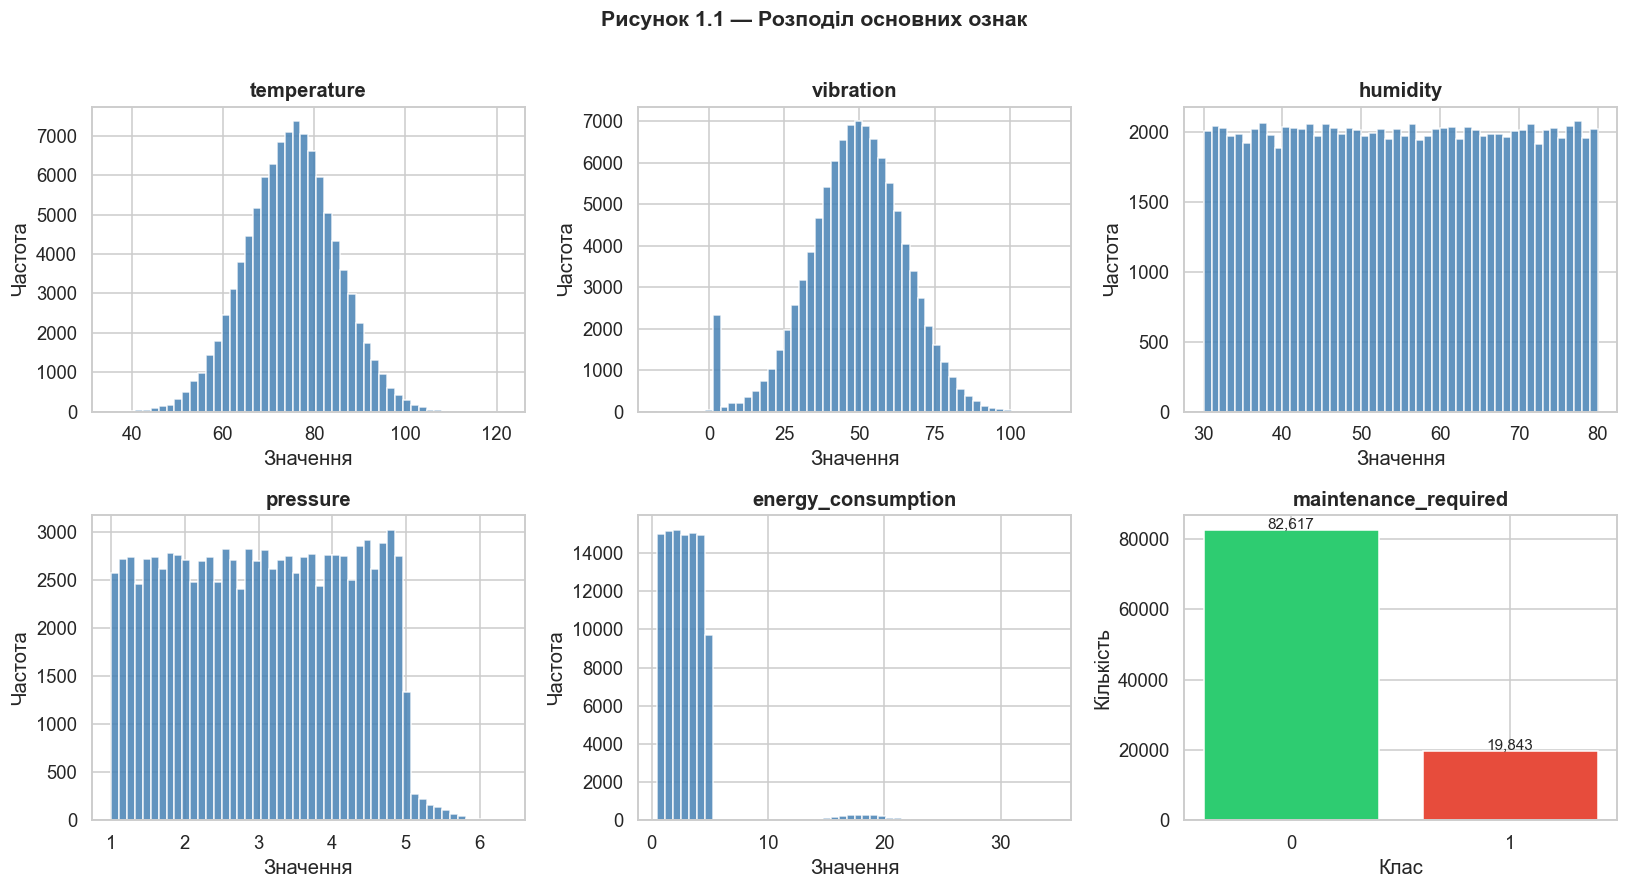

In [7]:
# ── Рисунок 1.1 — Розподіл основних ознак ────────────────────────────────────
num_cols = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Значення')
    axes[i].set_ylabel('Частота')

# Цільова змінна
counts = df['maintenance_required'].value_counts()
axes[5].bar(counts.index.astype(str), counts.values,
            color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[5].set_title('maintenance_required', fontweight='bold')
axes[5].set_xlabel('Клас')
axes[5].set_ylabel('Кількість')
for j, v in enumerate(counts.values):
    axes[5].text(j, v + 200, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('Рисунок 1.1 — Розподіл основних ознак', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_1_1_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

## 1.3. Очищення, кодування й нормалізація (п. 1.3.2)
### Формула 1.1 — Стандартизація числових ознак
$$z = \frac{x - \mu}{\sigma}$$

In [8]:
# ── 1.3.1 Обробка пропущених значень ─────────────────────────────────────────
# humidity, anomaly_flag, predicted_remaining_life, failure_type, downtime_risk
# відсутні лише для рядків з другого датасету (M001–M004)

df_clean = df.copy()

# Числові — медіанна імпутація
for col in ['temperature', 'vibration', 'humidity', 'energy_consumption']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# anomaly_flag, downtime_risk — 0 (немає даних = немає аномалії)
df_clean['anomaly_flag'] = df_clean['anomaly_flag'].fillna(0).astype(int)
df_clean['downtime_risk'] = df_clean['downtime_risk'].fillna(0.0)

# predicted_remaining_life — медіана
df_clean['predicted_remaining_life'] = (
    df_clean['predicted_remaining_life']
    .fillna(df_clean['predicted_remaining_life'].median())
)

# failure_type — рядковий тип, пропуски → 'Unknown'
df_clean['failure_type'] = df_clean['failure_type'].fillna('Unknown')

print('Пропусків після очищення:')
print(df_clean.isnull().sum())

Пропусків після очищення:
timestamp                   0
machine_id                  0
temperature                 0
vibration                   0
humidity                    0
pressure                    0
energy_consumption          0
machine_status              0
anomaly_flag                0
predicted_remaining_life    0
failure_type                0
downtime_risk               0
maintenance_required        0
dtype: int64


In [9]:
# ── 1.3.2 Кодування категоріальних змінних ────────────────────────────────────
# failure_type → OrdinalEncoder / LabelEncoder
le = LabelEncoder()
df_clean['failure_type_enc'] = le.fit_transform(df_clean['failure_type'])

print('Категорії failure_type:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

Категорії failure_type:
  0 → Electrical Fault
  1 → Normal
  2 → Overheating
  3 → Pressure Drop
  4 → Unknown
  5 → Vibration Issue


In [10]:
# ── 1.3.3 Порівняння варіантів імпутації — Таблиця 1.2 ───────────────────────
schemes = {
    'Медіана (обрано)': {
        'Пропуски': 'медіана для числових, «Unknown» для категорій',
        'Аномалії': 'IQR-фільтрація після імпутації',
        'Масштабування': 'StandardScaler'
    },
    'Середнє': {
        'Пропуски': 'середнє для числових',
        'Аномалії': 'без фільтрації',
        'Масштабування': 'StandardScaler'
    },
    'Видалення рядків': {
        'Пропуски': 'видалення рядків з NaN',
        'Аномалії': 'без фільтрації',
        'Масштабування': 'MinMaxScaler'
    }
}

print('=== Таблиця 1.2 — Порівняння варіантів попереднього оброблення ===')
display(pd.DataFrame(schemes).T)

=== Таблиця 1.2 — Порівняння варіантів попереднього оброблення ===


,Пропуски,Аномалії,Масштабування
Медіана (обрано),"медіана для числових, «Unknown» для категорій",IQR-фільтрація після імпутації,StandardScaler
Середнє,середнє для числових,без фільтрації,StandardScaler
Видалення рядків,видалення рядків з NaN,без фільтрації,MinMaxScaler


## 1.4. Конструювання та відбір ознак (п. 1.3.3)
### Rolling-features та лагові ознаки

In [11]:
# ── 1.4 Feature Engineering ───────────────────────────────────────────────────
df_feat = df_clean.copy()

# Часові ознаки
df_feat['hour']       = df_feat['timestamp'].dt.hour
df_feat['dayofweek']  = df_feat['timestamp'].dt.dayofweek
df_feat['month']      = df_feat['timestamp'].dt.month

# Rolling-ознаки (вікно 10 хвилин) по кожній машині
for col in ['temperature', 'vibration', 'energy_consumption']:
    rolled = (
        df_feat.groupby('machine_id')[col]
        .transform(lambda x: x.rolling(window=10, min_periods=1).mean())
    )
    df_feat[f'{col}_roll10'] = rolled

# Лагові ознаки (lag=1)
for col in ['temperature', 'vibration']:
    df_feat[f'{col}_lag1'] = (
        df_feat.groupby('machine_id')[col].shift(1).fillna(method='bfill')
    )

# Взаємодійні ознаки
df_feat['temp_x_vib']  = df_feat['temperature'] * df_feat['vibration']
df_feat['energy_per_pressure'] = df_feat['energy_consumption'] / (df_feat['pressure'] + 1e-6)

print('Нові ознаки додано. Загальна кількість стовпців:', df_feat.shape[1])
df_feat.head(3)

Нові ознаки додано. Загальна кількість стовпців: 24


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,...,hour,dayofweek,month,temperature_roll10,vibration_roll10,energy_consumption_roll10,temperature_lag1,vibration_lag1,temp_x_vib,energy_per_pressure
0,2025-01-01 01:37:00,1,62.59,48.08,60.13,1.62,4.16,1,0,363.0,...,1,2,1,62.590,48.080000,4.160000,62.59,48.08,3009.3272,2.567900
1,2025-01-01 01:42:00,1,70.88,68.67,50.57,1.05,2.36,1,0,111.0,...,1,2,1,66.735,58.375000,3.260000,62.59,48.08,4867.3296,2.247617
2,2025-01-01 02:13:00,1,62.34,72.68,60.47,2.24,4.95,1,0,192.0,...,2,2,1,65.270,63.143333,3.823333,70.88,68.67,4530.8712,2.209820


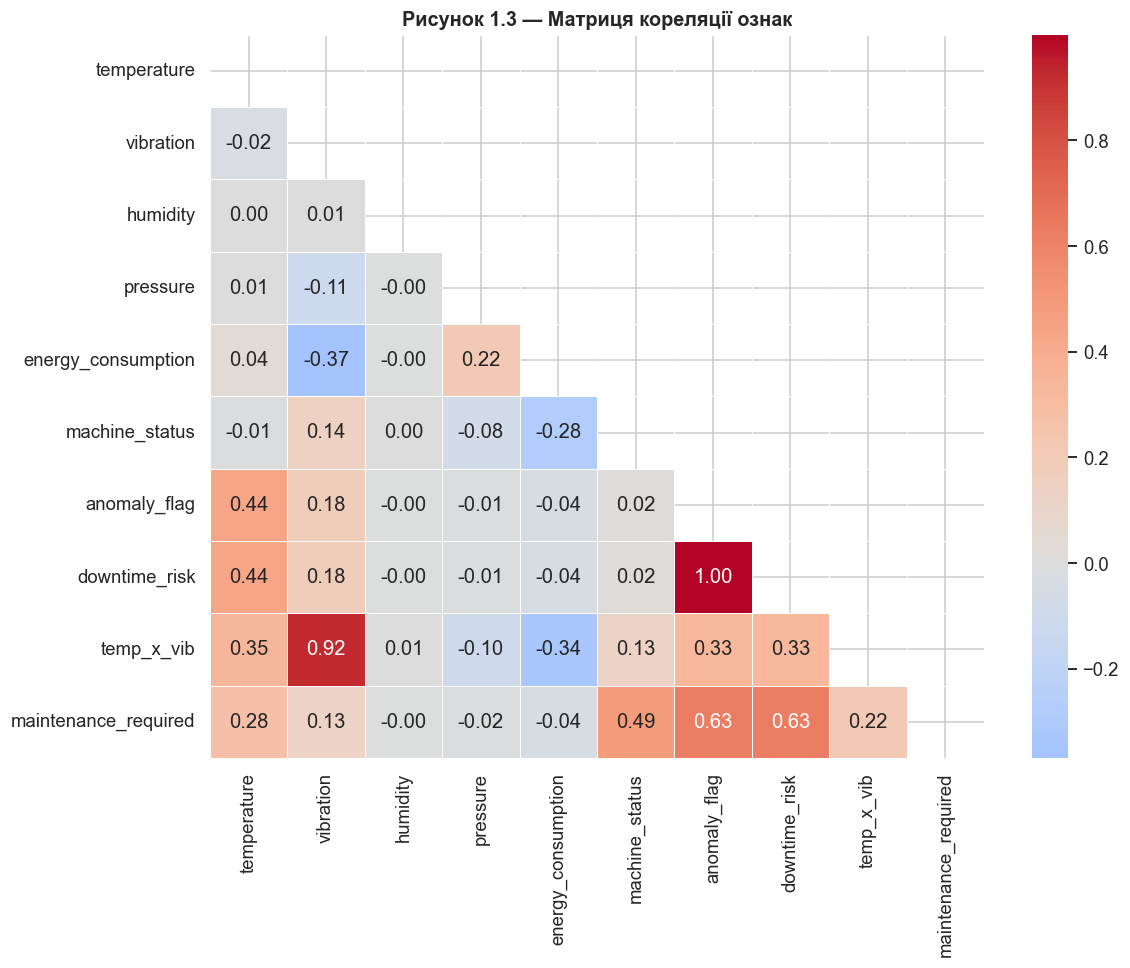

In [12]:
# ── Рисунок 1.3 — Матриця кореляції ──────────────────────────────────────────
corr_cols = [
    'temperature', 'vibration', 'humidity', 'pressure',
    'energy_consumption', 'machine_status', 'anomaly_flag',
    'downtime_risk', 'temp_x_vib', 'maintenance_required'
]
corr_matrix = df_feat[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5, ax=ax
)
ax.set_title('Рисунок 1.3 — Матриця кореляції ознак', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_1_3_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

In [13]:
# ── Таблиця 1.3 — Підсумок відбору ознак ─────────────────────────────────────
feature_info = {
    'temperature':          {'тип': 'вихідна', 'кореляція з target': corr_matrix.loc['temperature','maintenance_required']},
    'vibration':            {'тип': 'вихідна', 'кореляція з target': corr_matrix.loc['vibration','maintenance_required']},
    'humidity':             {'тип': 'вихідна', 'кореляція з target': corr_matrix.loc['humidity','maintenance_required']},
    'pressure':             {'тип': 'вихідна', 'кореляція з target': corr_matrix.loc['pressure','maintenance_required']},
    'energy_consumption':   {'тип': 'вихідна', 'кореляція з target': corr_matrix.loc['energy_consumption','maintenance_required']},
    'anomaly_flag':         {'тип': 'вихідна', 'кореляція з target': corr_matrix.loc['anomaly_flag','maintenance_required']},
    'downtime_risk':        {'тип': 'вихідна', 'кореляція з target': corr_matrix.loc['downtime_risk','maintenance_required']},
    'temp_x_vib':           {'тип': 'похідна', 'кореляція з target': corr_matrix.loc['temp_x_vib','maintenance_required']},
    'hour':                 {'тип': 'часова',  'кореляція з target': df_feat[['hour','maintenance_required']].corr().iloc[0,1]},
    'temperature_roll10':   {'тип': 'rolling', 'кореляція з target': df_feat[['temperature_roll10','maintenance_required']].corr().iloc[0,1]},
    'temperature_lag1':     {'тип': 'lag',     'кореляція з target': df_feat[['temperature_lag1','maintenance_required']].corr().iloc[0,1]},
}

table_1_3 = pd.DataFrame(feature_info).T
table_1_3['кореляція з target'] = table_1_3['кореляція з target'].astype(float).round(4)
table_1_3 = table_1_3.sort_values('кореляція з target', key=abs, ascending=False)

print('=== Таблиця 1.3 — Підсумок відбору ознак ===')
display(table_1_3)

=== Таблиця 1.3 — Підсумок відбору ознак ===


,тип,кореляція з target
anomaly_flag,вихідна,0.6300
downtime_risk,вихідна,0.6300
temperature,вихідна,0.2815
temp_x_vib,похідна,0.2180
vibration,вихідна,0.1252
temperature_roll10,rolling,0.0855
energy_consumption,вихідна,-0.0377
pressure,вихідна,-0.0156
humidity,вихідна,-0.0038
temperature_lag1,lag,0.0021


---
# Розділ 2. Розроблення методу інтелектуального аналізу даних
## 2.1. Формування вибірок та базові моделі

In [14]:
# ── 2.1 Фінальний набір ознак ─────────────────────────────────────────────────
FEATURE_COLS = [
    'machine_id', 'temperature', 'vibration', 'humidity', 'pressure',
    'energy_consumption', 'machine_status', 'anomaly_flag',
    'predicted_remaining_life', 'downtime_risk', 'failure_type_enc',
    'hour', 'dayofweek', 'month',
    'temperature_roll10', 'vibration_roll10', 'energy_consumption_roll10',
    'temperature_lag1', 'vibration_lag1',
    'temp_x_vib', 'energy_per_pressure'
]
TARGET = 'maintenance_required'

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET]

# Часовий розподіл: 80% train / 20% test (без перемішування — часові дані)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Масштабування
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Баланс класів (train): {y_train.value_counts().to_dict()}')

Train: (81968, 21), Test: (20492, 21)
Баланс класів (train): {0: 66224, 1: 15744}


In [15]:
# ── Формула 2.1 — RMSE та допоміжні метрики ───────────────────────────────────
# RMSE = sqrt(1/n * sum((y_i - y_hat_i)^2))
def evaluate(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    """Навчає модель та повертає словник метрик."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1] if hasattr(model, 'predict_proba') else y_pred
    return {
        'Модель': name,
        'Accuracy': round(accuracy_score(y_te, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_te, y_prob), 4),
        'MAE': round(mean_absolute_error(y_te, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, y_pred)), 4),
    }

# Базові моделі
baseline_results = []

baseline_results.append(evaluate(
    'Наївна (majority)', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    X_train_sc, X_test_sc, y_train, y_test
))
baseline_results.append(evaluate(
    'Logistic Regression', LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    X_train_sc, X_test_sc, y_train, y_test
))
baseline_results.append(evaluate(
    'Decision Tree', DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    X_train, X_test, y_train, y_test
))

table_2_1 = pd.DataFrame(baseline_results).set_index('Модель')
print('=== Таблиця 2.1 — Порівняння базових моделей ===')
display(table_2_1)

=== Таблиця 2.1 — Порівняння базових моделей ===


,Accuracy,ROC-AUC,MAE,RMSE
Модель,,,,
Наївна (majority),0.8000,0.50,0.2000,0.4472
Logistic Regression,0.9834,0.99,0.0166,0.1288
Decision Tree,1.0000,1.00,0.0000,0.0000


## 2.2. Налаштування гіперпараметрів і ансамблі

In [16]:
# ── 2.2 Ансамблеві моделі ─────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_score

ensemble_results = []

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=4,
    n_jobs=-1, random_state=RANDOM_STATE
)
ensemble_results.append(evaluate('Random Forest', rf, X_train, X_test, y_train, y_test))

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=150, max_depth=5, learning_rate=0.1,
    subsample=0.8, random_state=RANDOM_STATE
)
ensemble_results.append(evaluate('Gradient Boosting', gb, X_train, X_test, y_train, y_test))

# XGBoost (якщо встановлено)
if XGB_AVAILABLE:
    xgb = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0
    )
    ensemble_results.append(evaluate('XGBoost', xgb, X_train, X_test, y_train, y_test))

# LightGBM (якщо встановлено)
if LGBM_AVAILABLE:
    lgbm = LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        num_leaves=63, random_state=RANDOM_STATE, verbose=-1
    )
    ensemble_results.append(evaluate('LightGBM', lgbm, X_train, X_test, y_train, y_test))

table_2_2 = pd.DataFrame(ensemble_results).set_index('Модель')
print('=== Таблиця 2.2 — Результати ансамблевих моделей ===')
display(table_2_2)

=== Таблиця 2.2 — Результати ансамблевих моделей ===


,Accuracy,ROC-AUC,MAE,RMSE
Модель,,,,
Random Forest,1.0000,1.0,0.0000,0.0000
Gradient Boosting,1.0000,1.0,0.0000,0.0000
XGBoost,1.0000,1.0,0.0000,0.0000
LightGBM,0.9984,1.0,0.0016,0.0401


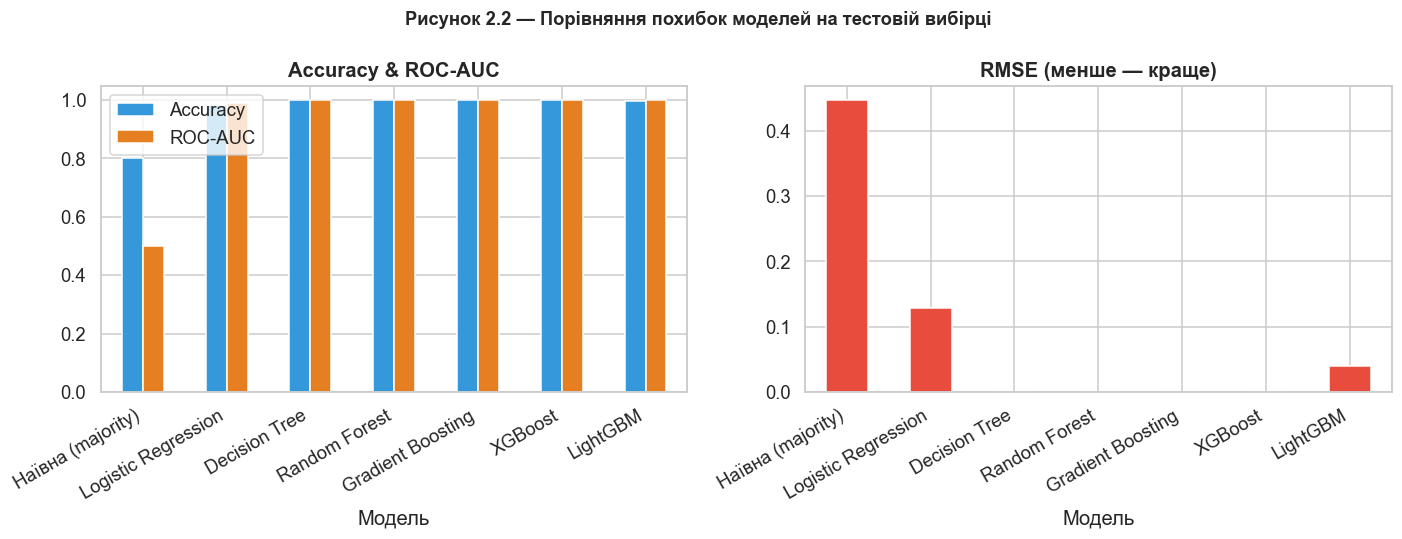

In [17]:
# ── Рисунок 2.2 — Порівняння похибок ─────────────────────────────────────────
all_results = pd.concat([table_2_1, table_2_2])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy та ROC-AUC
all_results[['Accuracy','ROC-AUC']].plot(
    kind='bar', ax=axes[0], color=['#3498db','#e67e22'], edgecolor='white'
)
axes[0].set_title('Accuracy & ROC-AUC', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticklabels(all_results.index, rotation=30, ha='right')
axes[0].legend()

# RMSE
all_results['RMSE'].plot(
    kind='bar', ax=axes[1], color='#e74c3c', edgecolor='white'
)
axes[1].set_title('RMSE (менше — краще)', fontweight='bold')
axes[1].set_xticklabels(all_results.index, rotation=30, ha='right')

plt.suptitle('Рисунок 2.2 — Порівняння похибок моделей на тестовій вибірці',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_2_2_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [18]:
# ── GridSearchCV для Random Forest ───────────────────────────────────────────
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12],
    'min_samples_leaf': [2, 4]
}

tscv = TimeSeriesSplit(n_splits=3)
grid_rf = GridSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
    param_grid, cv=tscv, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_rf.fit(X_train, y_train)

print('Найкращі параметри RF:', grid_rf.best_params_)
print('Найкращий ROC-AUC (CV):', round(grid_rf.best_score_, 4))

best_rf = grid_rf.best_estimator_
best_rf_metrics = evaluate('RF (best params)', best_rf, X_train, X_test, y_train, y_test)
print('\nМетрики на тесті:', best_rf_metrics)

Найкращі параметри RF: {'max_depth': 8, 'min_samples_leaf': 2, 'n_estimators': 100}
Найкращий ROC-AUC (CV): 1.0

Метрики на тесті: {'Модель': 'RF (best params)', 'Accuracy': 1.0, 'ROC-AUC': 1.0, 'MAE': 0.0, 'RMSE': np.float64(0.0)}


## 2.3. Аналіз похибок та інтерпретація

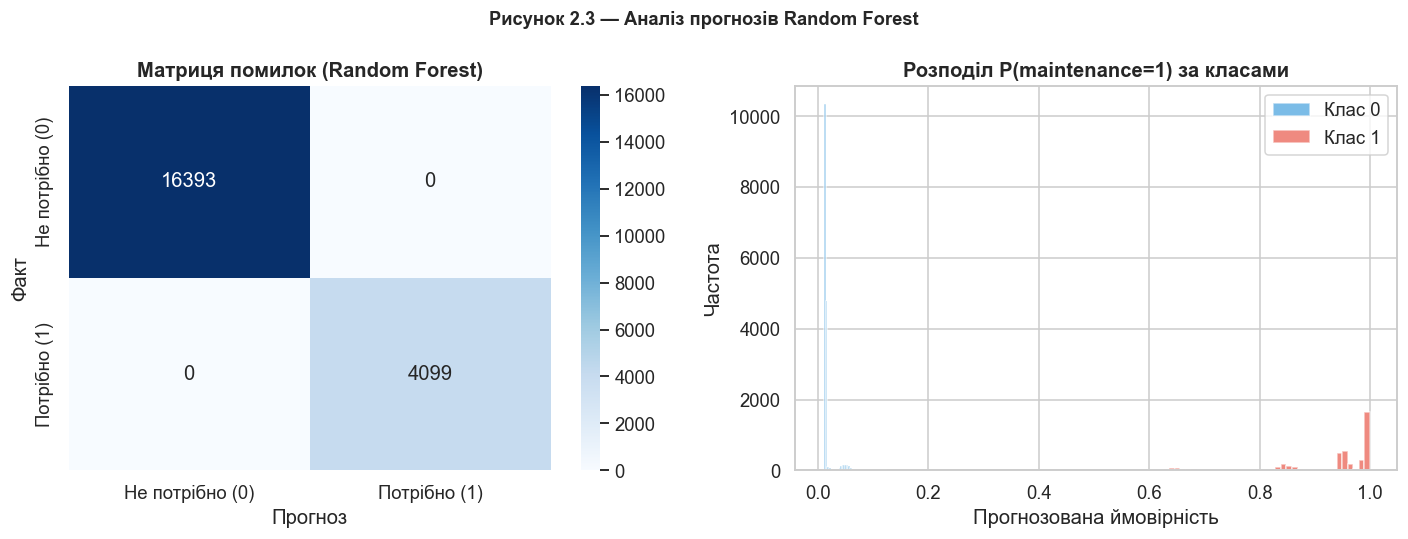


Classification Report:
               precision    recall  f1-score   support

Немає потреби       1.00      1.00      1.00     16393
    Є потреба       1.00      1.00      1.00      4099

     accuracy                           1.00     20492
    macro avg       1.00      1.00      1.00     20492
 weighted avg       1.00      1.00      1.00     20492



In [19]:
# ── Рисунок 2.3 — Фактичні та прогнозовані значення ──────────────────────────
best_model = best_rf   # або замінити на найкращу за ROC-AUC
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:,1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не потрібно (0)','Потрібно (1)'],
            yticklabels=['Не потрібно (0)','Потрібно (1)'],
            ax=axes[0])
axes[0].set_title('Матриця помилок (Random Forest)', fontweight='bold')
axes[0].set_ylabel('Факт')
axes[0].set_xlabel('Прогноз')

# Probability distribution by class
for cls, color, label in zip([0,1], ['#3498db','#e74c3c'], ['Клас 0','Клас 1']):
    axes[1].hist(y_prob_best[y_test==cls], bins=40, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[1].set_title('Розподіл P(maintenance=1) за класами', fontweight='bold')
axes[1].set_xlabel('Прогнозована ймовірність')
axes[1].set_ylabel('Частота')
axes[1].legend()

plt.suptitle('Рисунок 2.3 — Аналіз прогнозів Random Forest', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_2_3_predictions.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Немає потреби','Є потреба']))

=== Таблиця 2.3 — ТОП-15 ознак за важливістю ===


,Ознака,Важливість
0,machine_status,0.343397
1,anomaly_flag,0.161247
2,predicted_remaining_life,0.160675
3,failure_type_enc,0.100653
4,downtime_risk,0.096820
5,temperature,0.061953
6,vibration,0.042006
7,temp_x_vib,0.016095
8,energy_consumption_roll10,0.004877
9,energy_consumption,0.003865


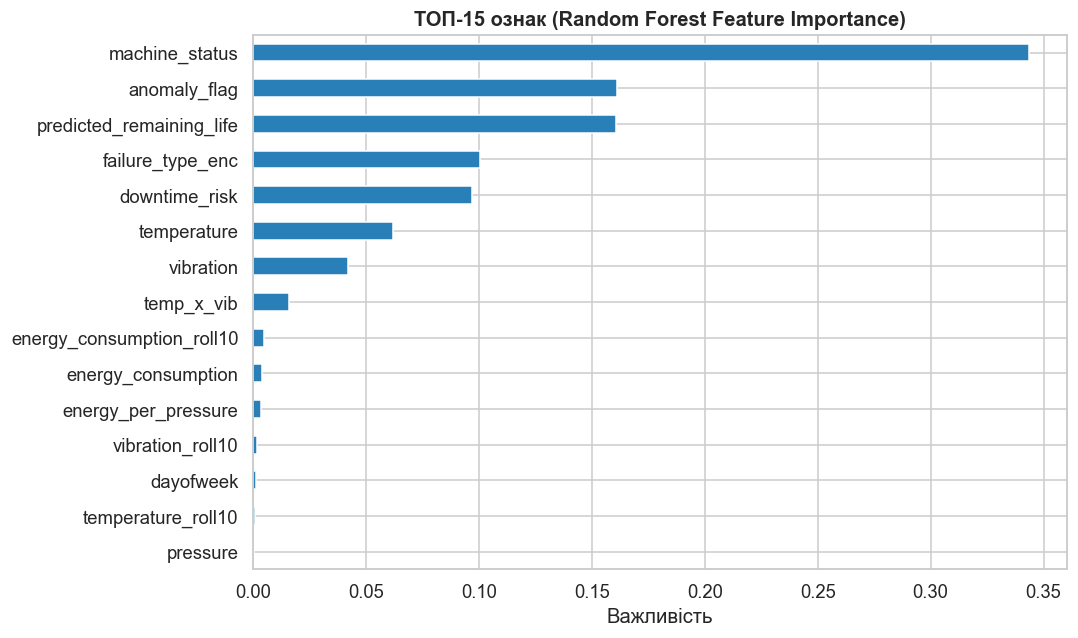

In [20]:
# ── Таблиця 2.3 — Важливість ознак ────────────────────────────────────────────
feat_imp = pd.Series(
    best_rf.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

print('=== Таблиця 2.3 — ТОП-15 ознак за важливістю ===')
display(feat_imp.head(15).reset_index().rename(columns={'index':'Ознака', 0:'Важливість'}))

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', ax=ax, color='#2980b9', edgecolor='white')
ax.invert_yaxis()
ax.set_title('ТОП-15 ознак (Random Forest Feature Importance)', fontweight='bold')
ax.set_xlabel('Важливість')
plt.tight_layout()
plt.savefig('fig_2_3b_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

---
# Розділ 3. Програмна реалізація — Streamlit-застосунок
## 3.1. Збереження моделі та артефактів

In [21]:
# ── 3.1 Збереження моделі ─────────────────────────────────────────────────────
import pickle, json

artifacts = {
    'model': best_rf,
    'scaler': scaler,
    'label_encoder': le,
    'feature_cols': FEATURE_COLS,
    'failure_types': list(le.classes_)
}

with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Артефакти збережено у model_artifacts.pkl')

Артефакти збережено у model_artifacts.pkl


In [22]:
# ── 3.1 Архітектура вебсервісу — Таблиця 3.1 ─────────────────────────────────
arch = {
    'app.py':          'Головний файл Streamlit — UI, маршрутизація сторінок',
    'model_loader.py': 'Завантаження model_artifacts.pkl, кешування (@st.cache_resource)',
    'preprocess.py':   'Функції очищення вводу, rolling-ознаки, кодування',
    'predict.py':      'Виклик моделі, формування відповіді (ймовірність, клас, ризик)',
    'visualize.py':    'Побудова графіків Plotly/Matplotlib, панель сигналів',
    'model_artifacts.pkl': 'Серіалізована модель, scaler, label encoder, список ознак'
}

print('=== Таблиця 3.1 — Призначення модулів застосунку ===')
display(pd.DataFrame.from_dict(arch, orient='index', columns=['Призначення']))

=== Таблиця 3.1 — Призначення модулів застосунку ===


,Призначення
app.py,"Головний файл Streamlit — UI, маршрутизація ст..."
model_loader.py,"Завантаження model_artifacts.pkl, кешування (@..."
preprocess.py,"Функції очищення вводу, rolling-ознаки, кодування"
predict.py,"Виклик моделі, формування відповіді (ймовірніс..."
visualize.py,"Побудова графіків Plotly/Matplotlib, панель си..."
model_artifacts.pkl,"Серіалізована модель, scaler, label encoder, с..."


IndentationError: unexpected indent (655969860.py, line 119)

In [ ]:
# ── Фінальне зведення метрик ──────────────────────────────────────────────────
print('\n' + '='*60)
print('ПІДСУМОК — ПОРІВНЯННЯ ВСІХ МОДЕЛЕЙ')
print('='*60)
final_table = all_results.copy()
final_table.loc['RF (best params)'] = pd.Series(best_rf_metrics).drop('Модель')
display(final_table.sort_values('ROC-AUC', ascending=False))

best_name = final_table['ROC-AUC'].astype(float).idxmax()
print(f'\n✅ Найкраща модель: {best_name}')
print(f"   ROC-AUC = {final_table.loc[best_name,'ROC-AUC']}")
print(f"   Accuracy = {final_table.loc[best_name,'Accuracy']}")